# Numerical Cross-Validation

Four independent checks validating the entire numerical stack:
1. Green's function = eigendecomposition LDOS (machine-precision agreement)
2. PBC has no gap states; OBC has exactly the expected edge mode
3. Localization length matches analytical prediction to < 5 %
4. LDOS sum rule: $\int \rho_i(\omega)\,d\omega = 1$ per site


In [1]:
import sys
sys.path.insert(0, "..")   # find src/nh_topo from notebooks/

import numpy as np
import matplotlib.pyplot as plt
import nh_topo as nt
from nh_topo.config import load_all, get_physics_params, get_figure_dir
from pathlib import Path

cfg = load_all(config_dir="../config")
p   = get_physics_params(cfg)

# Quick confirmation
print(f"t1={p['t1']}, t2={p['t2']}, gamma={p['gamma']}, N={p['N']}")
print(f"Topological: t2/t1 = {p['t2']/p['t1']:.2f} > 1 → |nu|={nt.topological_invariant(p['t1'], p['t2'])}")


t1=0.8, t2=1.2, gamma=0.3, N=20
Topological: t2/t1 = 1.50 > 1 → |nu|=1


In [2]:
import scipy.linalg as la

H_obc = nt.build_ssh(p['N'], p['t1'], p['t2'], p['gamma'])
H_pbc = nt.build_ssh_pbc(p['N'], p['t1'], p['t2'], p['gamma'])
eta   = p['eta']

# ── Check 1: GF vs eigdecomp ─────────────────────────────────────────────
omegas_check = np.linspace(-2.5, 2.5, 400)
sites_check  = [0, 5, 10, 20, 39]
max_err = 0
for site in sites_check:
    gf = nt.ldos_spectrum(H_obc, site, omegas_check, eta)
    ed = np.array([nt.ldos_eigdecomp(H_obc, site, w, eta) for w in omegas_check])
    err = float(np.max(np.abs(gf - ed)))
    max_err = max(max_err, err)
    print(f"  site {site:2d}: max|GF-ED| = {err:.2e}")
assert max_err < 1e-10, f"Check 1 FAILED: max error = {max_err:.2e}"
print(f"CHECK 1 PASSED  (max error {max_err:.2e} < 1e-10)\n")

# ── Check 2: PBC vs OBC ──────────────────────────────────────────────────
obc_gap = la.eigvals(H_obc).real; obc_gap = obc_gap[np.abs(obc_gap) < 0.1]
pbc_gap = la.eigvals(H_pbc).real; pbc_gap = pbc_gap[np.abs(pbc_gap) < 0.1]
print(f"  OBC: {len(obc_gap)} state(s) in gap  |  PBC: {len(pbc_gap)} state(s) in gap")
assert len(obc_gap) >= 1 and len(pbc_gap) == 0
print(f"CHECK 2 PASSED  (edge mode in OBC, absent in PBC)\n")

# ── Check 3: Localization length ─────────────────────────────────────────
evals, evecs = nt.diagonalize(H_obc)
xi_th  = nt.localization_length(p['t1'], p['t2'])
xi_fit = nt.fit_localization_length(evals, evecs, p['N'])
err3   = abs(xi_th - xi_fit) / xi_th
print(f"  xi_theory = {xi_th:.4f},  xi_fit = {xi_fit:.4f},  error = {err3*100:.2f}%")
assert err3 < 0.05, f"Check 3 FAILED: {err3*100:.1f}% error"
print(f"CHECK 3 PASSED  (localization length error {err3*100:.2f}% < 5%)\n")

# ── Check 4: Sum rule ────────────────────────────────────────────────────
omegas_wide = np.linspace(-8, 8, 2000)
sites_sr = [0, 5, 10, 20, 30, 39]
sr_errors = []
for s in sites_sr:
    rho = nt.ldos_spectrum(H_obc, s, omegas_wide, eta=0.05)
    integral = float(np.trapezoid(rho, omegas_wide))
    sr_errors.append(abs(integral - 1.0))
    print(f"  site {s:2d}: integral = {integral:.5f}")
assert max(sr_errors) < 0.05
print(f"CHECK 4 PASSED  (sum rule max error {max(sr_errors):.4f} < 0.05)\n")
print("=== ALL VALIDATION CHECKS PASSED ===")


  site  0: max|GF-ED| = 6.08e-14
  site  5: max|GF-ED| = 3.16e-15
  site 10: max|GF-ED| = 2.33e-15
  site 20: max|GF-ED| = 6.38e-15
  site 39: max|GF-ED| = 1.86e-15
CHECK 1 PASSED  (max error 6.08e-14 < 1e-10)

  OBC: 2 state(s) in gap  |  PBC: 0 state(s) in gap
CHECK 2 PASSED  (edge mode in OBC, absent in PBC)

  xi_theory = 2.4663,  xi_fit = 2.3905,  error = 3.07%
CHECK 3 PASSED  (localization length error 3.07% < 5%)

  site  0: integral = 0.99590
  site  5: integral = 0.97149
  site 10: integral = 0.99561
  site 20: integral = 0.99561
  site 30: integral = 0.99561
  site 39: integral = 0.97196
CHECK 4 PASSED  (sum rule max error 0.0285 < 0.05)

=== ALL VALIDATION CHECKS PASSED ===


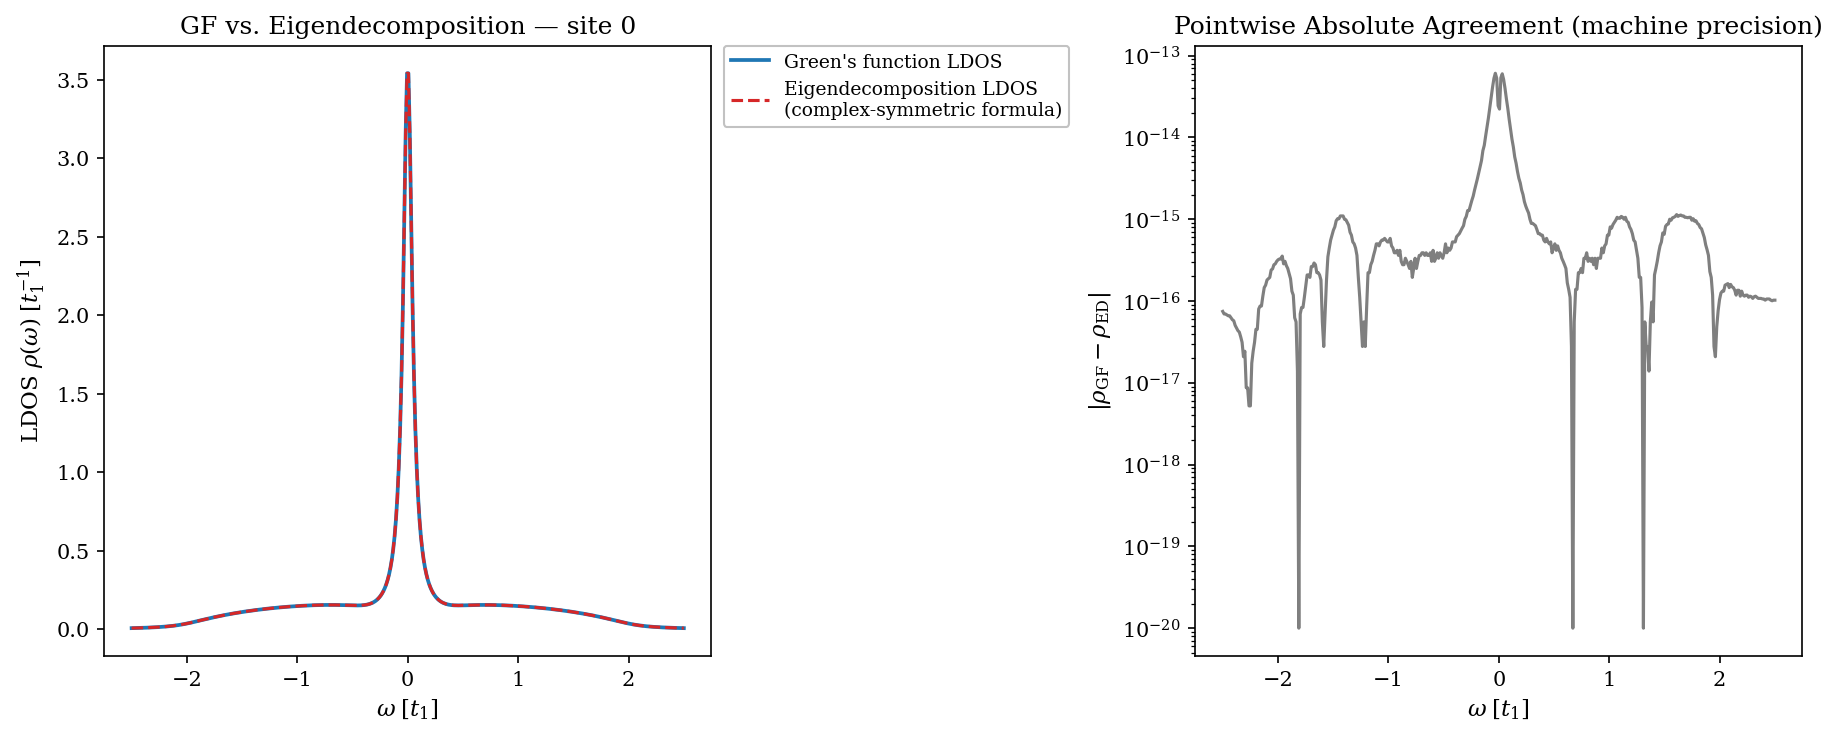

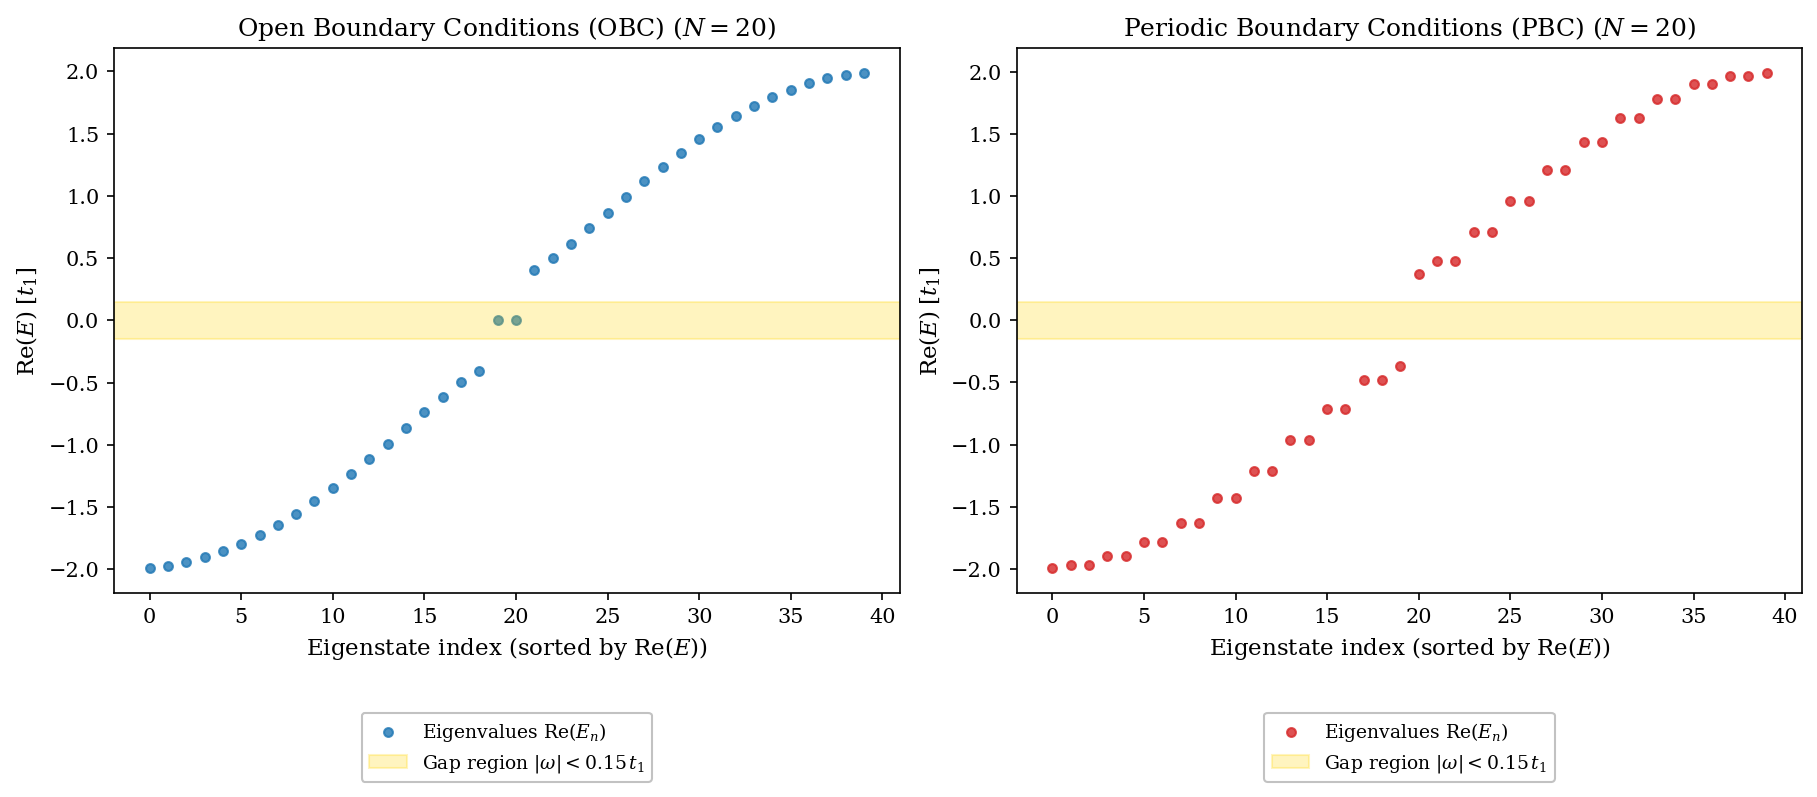

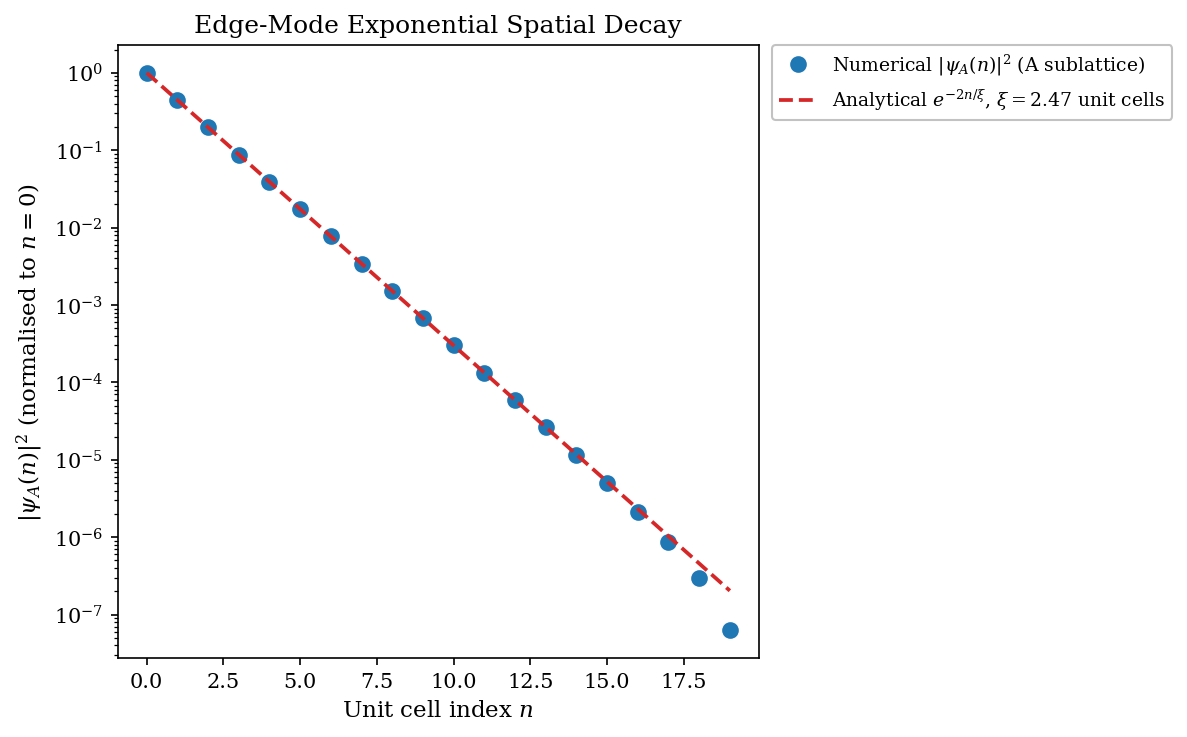

In [3]:
# --- Plots ---
# GF vs eigdecomp comparison (site 0)
rho_gf = nt.ldos_spectrum(H_obc, 0, omegas_check, eta)
rho_ed = np.array([nt.ldos_eigdecomp(H_obc, 0, w, eta) for w in omegas_check])
fig, axes = nt.plotting.plot_gf_vs_eigdecomp(omegas_check, rho_gf, rho_ed, site=0)
nt.plotting.save_fig(fig, Path('..') / get_figure_dir(cfg, '08_numerical_validation'), "01_gf_vs_eigdecomp")
plt.show()

# PBC vs OBC
evals_obc_sorted = np.sort(la.eigvals(H_obc).real)
evals_pbc_sorted = np.sort(la.eigvals(H_pbc).real)
fig, axes = nt.plotting.plot_pbc_obc(evals_obc_sorted, evals_pbc_sorted, p['N'], p['gap_hw'])
nt.plotting.save_fig(fig, Path('..') / get_figure_dir(cfg, '08_numerical_validation'), "02_pbc_vs_obc")
plt.show()

# Localization length
xi_th = nt.localization_length(p['t1'], p['t2'])
em_idx = nt.find_edge_modes(evals, evecs)['protected_idx'][0]
psi    = evecs[:, em_idx]
int_A  = np.abs(psi[0::2])**2; int_A /= int_A[0]
fig, ax = nt.plotting.plot_localization_length(np.arange(p['N']), int_A, xi_th)
nt.plotting.save_fig(fig, Path('..') / get_figure_dir(cfg, '08_numerical_validation'), "03_localization_length")
plt.show()
